# Notebook 01 — Mecanismo de Atención desde cero

**Bootcamp Bio-LLMs · Módulo 1 · Sesión 1 de 3**
Proyecto posdoctoral CICESE — Modelos de lenguaje para venómica integrativa de *Conus*.

---

## Objetivos de este notebook

1. Entender por qué la atención es la operación adecuada para secuencias biológicas (vs RNN/CNN).
2. Implementar el producto escalado de atención (*scaled dot-product attention*) **desde cero**, sin usar `torch.nn.Transformer` ni `F.scaled_dot_product_attention`.
3. Extender a *multi-head attention*.
4. Visualizar la matriz de atención sobre una secuencia toy de conotoxina y verificar que aprende patrones interpretables.

## Pre-requisitos

* PyTorch ≥ 2.0
* matplotlib
* numpy

## Bibliografía obligatoria asociada

> Vaswani, A. *et al.* (2017). **Attention Is All You Need.** *NeurIPS 30*.
> Léelo en paralelo a este notebook (Secciones 3.2 y 3.2.2 del paper).

## 0. Imports y configuración de semilla

Fijamos la semilla para reproducibilidad — crítico en investigación científica.

In [4]:
# --- PATCH MPS (auto-inyectado) ---
import sys, os
_SCRIPTS = os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts'))
if _SCRIPTS not in sys.path:
    sys.path.insert(0, _SCRIPTS)
from device_utils import get_device, set_seed  # noqa: E402
device = get_device()
# --- fin patch ---

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Semilla reproducible
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dispositivo
device = get_device()
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {device}")


[device_utils] PyTorch: 2.12.1
[device_utils] Dispositivo seleccionado: mps
[device_utils] MPS backend disponible (Apple Silicon).
[device_utils] PYTORCH_ENABLE_MPS_FALLBACK=1
[device_utils] PyTorch: 2.12.1
[device_utils] Dispositivo seleccionado: mps
[device_utils] MPS backend disponible (Apple Silicon).
[device_utils] PYTORCH_ENABLE_MPS_FALLBACK=1
PyTorch: 2.12.1
Dispositivo: mps


## 1. ¿Por qué atención para secuencias biológicas?

En la Figura 1a del paper DNABERT (Ji et al. 2021) se contrastan tres formas de propagar información en una secuencia:

| Arquitectura | Cómo desarrolla representaciones | Limitación clave para biología |
|---|---|---|
| **RNN/LSTM** | Propaga estado oculto secuencialmente $h_t = f(h_{t-1}, x_t)$ | Gradientes se desvanecen → no captura dependencias largas (operón completo, enhancer-promotor) |
| **CNN** | Convoluciona sobre ventanas locales de tamaño fijo | Recibe campo receptivo limitado; necesita muchas capas para "ver" lejos |
| **Transformer** | *Self-attention*: cada token atiende a todos los demás simultáneamente | $O(n^2)$ en memoria/cómputo, pero global desde la capa 1 |

Para conotoxinas, los **residuos de cisteína** que forman puentes disulfuro pueden estar separados por 20-30 aminoácidos en la secuencia primaria pero ser interdependientes funcionalmente. La atención permite que la cisteína del extremo C atienda directamente a la del extremo N sin necesidad de propagación secuencial.

## 2. Producto escalado de atención: la ecuación central

Dada una matriz de entrada $X \in \mathbb{R}^{n \times d}$ (n tokens, d dimensiones), proyectamos en tres espacios:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

donde $W_Q, W_K \in \mathbb{R}^{d \times d_k}$ y $W_V \in \mathbb{R}^{d \times d_v}$ son matrices aprendidas.

La salida de atención es:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

**Intuición:**
* $QK^\top$ es una matriz $n \times n$ de scores de similitud entre cada par de tokens.
* Dividir por $\sqrt{d_k}$ evita que los logits crezcan demasiado y saturen el softmax (gradientes pequeños).
* El softmax convierte scores en pesos no negativos que suman 1.
* Multiplicar por $V$ produce una mezcla ponderada de los valores.

In [5]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Producto escalado de atención.

    Args
    ----
    Q : tensor (..., n_q, d_k)   queries
    K : tensor (..., n_k, d_k)   keys
    V : tensor (..., n_k, d_v)   values
    mask : tensor opcional broadcasteable a (..., n_q, n_k)
           True en posiciones a IGNORAR (se rellenarán con -inf antes del softmax).

    Returns
    -------
    output : tensor (..., n_q, d_v)
    attn   : tensor (..., n_q, n_k)   pesos de atención (post-softmax)
    """
    d_k = Q.size(-1)

    # 1. Scores brutos: (..., n_q, n_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # 2. Aplicar máscara (importante para padding o atención causal)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))

    # 3. Softmax sobre la última dimensión (sobre las keys)
    attn = F.softmax(scores, dim=-1)

    # 4. Mezcla ponderada de values
    output = torch.matmul(attn, V)

    return output, attn


# --- Test mínimo ---
n, d_k, d_v = 5, 8, 8
Q = torch.randn(n, d_k)
K = torch.randn(n, d_k)
V = torch.randn(n, d_v)

out, attn = scaled_dot_product_attention(Q, K, V)
print(f"Forma salida : {out.shape}      (esperado: ({n}, {d_v}))")
print(f"Forma attn   : {attn.shape}      (esperado: ({n}, {n}))")
print(f"Filas suman 1: {attn.sum(dim=-1)}  (esperado: tensor con 1.0 en cada posición)")

Forma salida : torch.Size([5, 8])      (esperado: (5, 8))
Forma attn   : torch.Size([5, 5])      (esperado: (5, 5))
Filas suman 1: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])  (esperado: tensor con 1.0 en cada posición)


### Ejercicio 2.1 — Verificación numérica

Comprueba que tu implementación coincide con la de PyTorch.


In [6]:
# Comparar con la implementación oficial de PyTorch (sólo como sanity check)
out_torch = F.scaled_dot_product_attention(Q, K, V)
out_ours, _ = scaled_dot_product_attention(Q, K, V)

max_diff = (out_torch - out_ours).abs().max().item()
print(f"Diferencia máxima vs F.scaled_dot_product_attention: {max_diff:.2e}")
assert max_diff < 1e-5, "¡Hay una discrepancia! Revisa la implementación."
print("✓ Implementación correcta.")

Diferencia máxima vs F.scaled_dot_product_attention: 1.79e-07
✓ Implementación correcta.


## 3. Por qué dividir por $\sqrt{d_k}$ — experimento empírico

Visualicemos qué pasa con la distribución de atención cuando $d_k$ crece **sin** escalar.

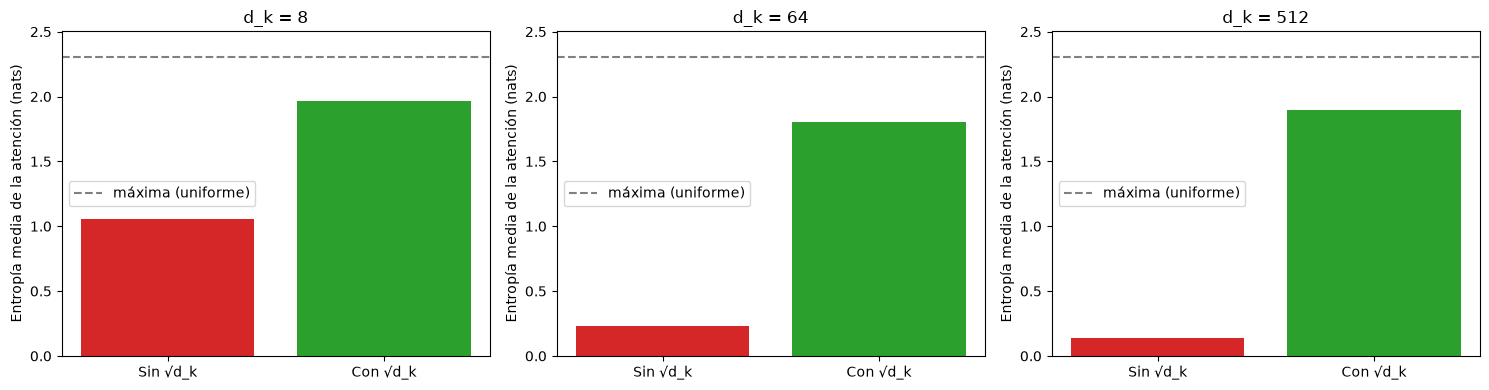


Observación: Sin escalado, a mayor d_k la atención colapsa en una sola posición (entropía → 0)
→ gradientes minúsculos → el modelo no aprende.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, d_k in zip(axes, [8, 64, 512]):
    Q = torch.randn(10, d_k)
    K = torch.randn(10, d_k)

    # SIN escalado
    scores_unscaled = Q @ K.T
    attn_unscaled = F.softmax(scores_unscaled, dim=-1)

    # CON escalado (correcto)
    scores_scaled = scores_unscaled / math.sqrt(d_k)
    attn_scaled = F.softmax(scores_scaled, dim=-1)

    entropy_unscaled = -(attn_unscaled * (attn_unscaled + 1e-9).log()).sum(-1).mean().item()
    entropy_scaled = -(attn_scaled * (attn_scaled + 1e-9).log()).sum(-1).mean().item()

    ax.bar(["Sin √d_k", "Con √d_k"], [entropy_unscaled, entropy_scaled],
           color=["#d62728", "#2ca02c"])
    ax.set_title(f"d_k = {d_k}")
    ax.set_ylabel("Entropía media de la atención (nats)")
    ax.set_ylim(0, math.log(10) + 0.2)
    ax.axhline(math.log(10), ls="--", color="gray", label="máxima (uniforme)")
    ax.legend()

plt.tight_layout()
plt.show()
print("\nObservación: Sin escalado, a mayor d_k la atención colapsa en una sola posición (entropía → 0)")
print("→ gradientes minúsculos → el modelo no aprende.")

## 4. Multi-head attention

Una sola cabeza fuerza al modelo a promediar todas las relaciones posibles en un único subespacio. **Multi-head** permite atender a $h$ subespacios diferentes en paralelo, cada uno aprendiendo un tipo de relación distinta (por ejemplo: relaciones cis vs trans, motivos cortos vs largos, contactos disulfuro vs estructura secundaria).

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W_O$$

donde

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

con $W_i^Q, W_i^K \in \mathbb{R}^{d \times d_k}$, $W_i^V \in \mathbb{R}^{d \times d_v}$, $W_O \in \mathbb{R}^{h\, d_v \times d}$.

Convencionalmente $d_k = d_v = d / h$, así que el costo total por capa es igual al de single-head con dimensión $d$ — multi-head es "gratis" en cómputo.

In [8]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention implementada desde cero (sin nn.MultiheadAttention)."""

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % num_heads == 0, f"d_model ({d_model}) debe ser divisible por num_heads ({num_heads})"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Proyecciones lineales. Las tres Q/K/V se fusionan en una sola matriz por eficiencia.
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        x    : (batch, seq_len, d_model)
        mask : (batch, 1, 1, seq_len)  con True en posiciones a ignorar (padding)
        """
        B, N, _ = x.shape

        # 1. Proyectar y dividir en cabezas: (B, N, d_model) -> (B, num_heads, N, d_k)
        Q = self.W_q(x).view(B, N, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Atención por cabeza (con broadcasting de la máscara)
        out, attn = scaled_dot_product_attention(Q, K, V, mask=mask)

        # 3. Concatenar cabezas: (B, num_heads, N, d_k) -> (B, N, d_model)
        out = out.transpose(1, 2).contiguous().view(B, N, self.d_model)

        # 4. Proyección final
        out = self.W_o(out)
        out = self.dropout(out)

        return out, attn  # devolvemos attn para visualizar después


# --- Test ---
mha = MultiHeadAttention(d_model=64, num_heads=8)
x = torch.randn(2, 10, 64)  # batch=2, seq_len=10
out, attn = mha(x)
print(f"Entrada     : {tuple(x.shape)}")
print(f"Salida      : {tuple(out.shape)}    (esperado: (2, 10, 64))")
print(f"Atención    : {tuple(attn.shape)}   (esperado: (2, 8, 10, 10))  ← 8 cabezas")
print(f"Parámetros  : {sum(p.numel() for p in mha.parameters()):,}")

Entrada     : (2, 10, 64)
Salida      : (2, 10, 64)    (esperado: (2, 10, 64))
Atención    : (2, 8, 10, 10)   (esperado: (2, 8, 10, 10))  ← 8 cabezas
Parámetros  : 16,384


## 5. Visualización de atención sobre una conotoxina

Vamos a tomar una secuencia tipo α-conotoxina y observar qué patrones de atención emergen con pesos **aleatorios** (no entrenados). Esto sirve como baseline: cualquier estructura interesante que aparezca después del entrenamiento (en el Notebook 3) será atribuible al aprendizaje, no a la inicialización.

**Secuencia de ejemplo:** α-GI de *Conus geographus*, mostrando el patrón de cisteínas del framework I (C-C-CC).

```
ECCNPACGRHYSC
0123456789...
```

In [9]:
# Vocabulario de aminoácidos (20 estándar + padding)
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

sequence = "ECCNPACGRHYSC"  # α-GI conotoxina (Conus geographus)
indices = torch.tensor([[aa_to_idx[aa] for aa in sequence]])  # (1, N)
print(f"Secuencia : {sequence}")
print(f"Cisteínas en posiciones: {[i for i, aa in enumerate(sequence) if aa == 'C']}")

# Embedding aleatorio (no entrenado)
d_model = 32
embed = nn.Embedding(len(AMINO_ACIDS), d_model)
x = embed(indices)  # (1, N, d_model)
print(f"Embedding : {tuple(x.shape)}")

# Multi-head con 4 cabezas
mha_demo = MultiHeadAttention(d_model=d_model, num_heads=4)
_, attn = mha_demo(x)
print(f"Atención  : {tuple(attn.shape)}")

Secuencia : ECCNPACGRHYSC
Cisteínas en posiciones: [1, 2, 6, 12]
Embedding : (1, 13, 32)
Atención  : (1, 4, 13, 13)


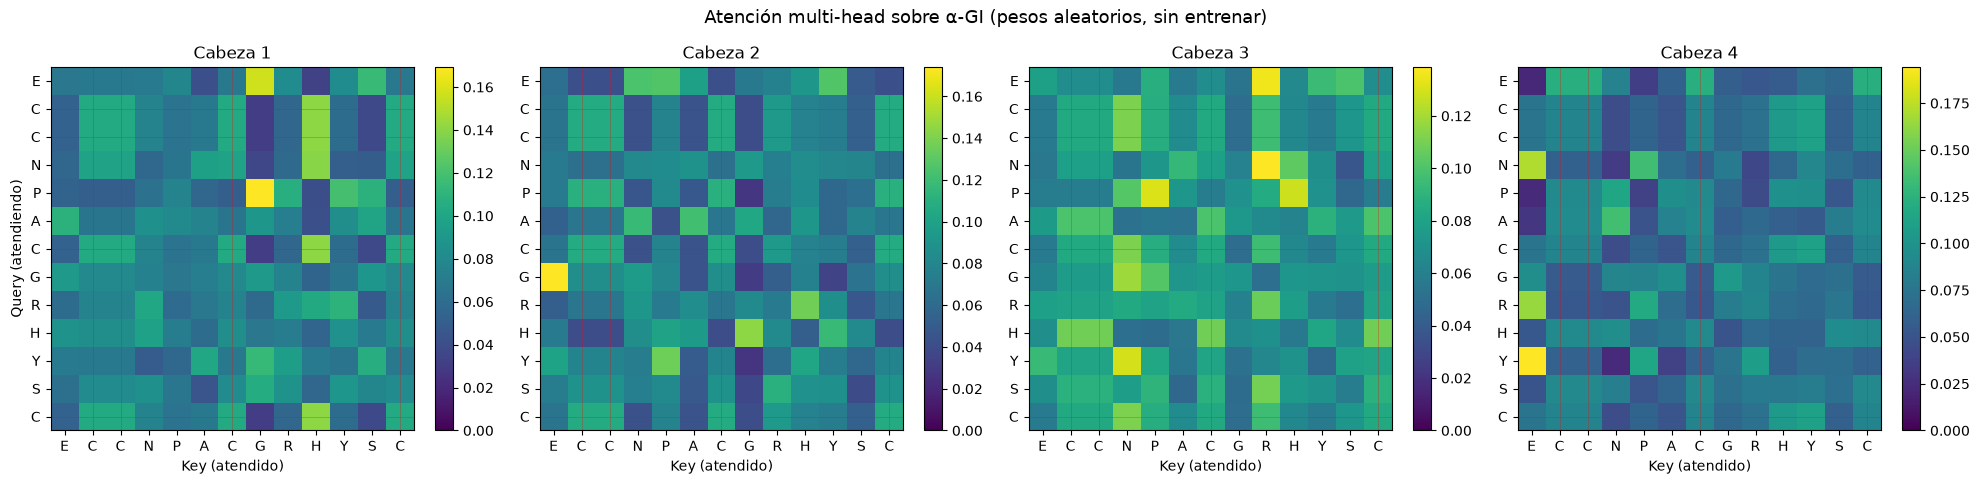


→ Sin entrenamiento, los patrones son ruido. Tras pre-entrenamiento MLM (Notebook 3)
  esperamos que cabezas específicas atiendan preferentemente entre cisteínas.


In [10]:
# Visualizar las 4 cabezas
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for h in range(4):
    ax = axes[h]
    A = attn[0, h].detach().numpy()  # (N, N)
    im = ax.imshow(A, cmap="viridis", vmin=0)
    ax.set_xticks(range(len(sequence)))
    ax.set_yticks(range(len(sequence)))
    ax.set_xticklabels(list(sequence), fontsize=10)
    ax.set_yticklabels(list(sequence), fontsize=10)
    ax.set_title(f"Cabeza {h+1}")
    ax.set_xlabel("Key (atendido)")
    if h == 0:
        ax.set_ylabel("Query (atendiendo)")

    # Marcar cisteínas
    cys_positions = [i for i, aa in enumerate(sequence) if aa == "C"]
    for cp in cys_positions:
        ax.axhline(cp, color="red", lw=0.4, alpha=0.5)
        ax.axvline(cp, color="red", lw=0.4, alpha=0.5)

    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Atención multi-head sobre α-GI (pesos aleatorios, sin entrenar)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n→ Sin entrenamiento, los patrones son ruido. Tras pre-entrenamiento MLM (Notebook 3)")
print("  esperamos que cabezas específicas atiendan preferentemente entre cisteínas.")

## 6. Ejercicios de consolidación

### Ejercicio 6.1 — Máscara de padding
Implementa una función `make_padding_mask(token_ids, pad_id)` que devuelva una máscara broadcasteable a `(B, num_heads, N, N)` con `True` donde haya tokens de padding.

### Ejercicio 6.2 — Máscara causal
Crea una máscara triangular superior para atención autorregresiva (como GPT). Pista: `torch.triu(torch.ones(N, N), diagonal=1).bool()`. Aplícala a una secuencia y verifica que cada token sólo "ve" a sí mismo y a los anteriores.

### Ejercicio 6.3 — Complejidad
Mide empíricamente el tiempo de un forward de `MultiHeadAttention` para `seq_len` ∈ {64, 256, 1024, 4096} con `d_model=128, num_heads=8`. Grafica tiempo vs `seq_len` en escala log-log. Verifica la pendiente cuadrática que motiva los SSMs (HyenaDNA, Mamba) del Módulo 3.

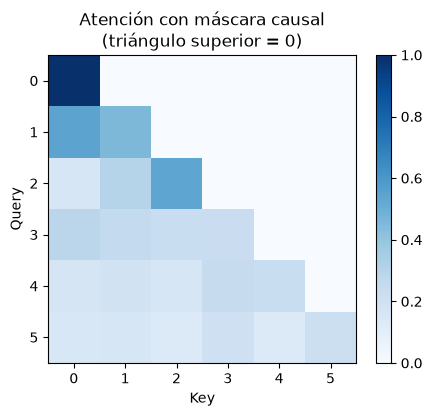

In [11]:
# Solución parcial del Ejercicio 6.2 (máscara causal)
def make_causal_mask(seq_len: int) -> torch.Tensor:
    """Devuelve máscara causal (True = no atender) de forma (1, 1, N, N)."""
    return torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1).unsqueeze(0).unsqueeze(0)


# Verificar
N = 6
causal_mask = make_causal_mask(N)
x_demo = torch.randn(1, N, 32)
_, attn_causal = MultiHeadAttention(32, 4)(x_demo, mask=causal_mask)

plt.figure(figsize=(5, 4))
plt.imshow(attn_causal[0, 0].detach().numpy(), cmap="Blues")
plt.title("Atención con máscara causal\n(triángulo superior = 0)")
plt.xlabel("Key"); plt.ylabel("Query")
plt.colorbar()
plt.show()

## 7. Próximos pasos

| Notebook | Tema | Lo que añade |
|---|---|---|
| **02** | Bloque encoder completo | Codificación posicional sinusoidal, FFN, LayerNorm, residuales — el bloque entero del Transformer |
| **03** | Pre-entrenamiento MLM | Aplicar el encoder a CDS de conotoxinas con masked codon prediction y reportar perplejidad |

### Lectura para mañana

Vaswani et al. (2017), secciones 3.1 (Encoder), 3.2 (Atención) y 5.4 (Regularización).
Toma notas sobre por qué los autores eligieron $h=8$ cabezas y $d_{ff}=4 \cdot d_{model}$ — son decisiones que reaparecerán en DNABERT y NT.

---

**Reproducibilidad.** Versión PyTorch usada en este notebook:


In [12]:
import sys
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"Semilla  : {SEED}")

Python   : 3.11.15
PyTorch  : 2.12.1
NumPy    : 2.4.6
CUDA     : False
Semilla  : 42
